# Image Generation Using Generative Adversarial Network (GAN)

**Course :** Deep Learning

**Name :** Delon Tantri Wijaya

**NIM :** 280239823

**Dataset** :

**Overhead-MNIST**

Classes used:

- Stadium
- Oil Gas Field

**Image Size:**

- 28 × 28 pixels
- Grayscale

## Objective

The objective of this project is to develop a Generative Adversarial Network (GAN) model for image generation using the Overhead-MNIST dataset. Two GAN architectures, namely a baseline GAN and an improved GAN, will be implemented and compared. The performance of both models will be assessed using the Fréchet Inception Distance (FID), which measures the similarity between the distribution of generated images and real images. A lower FID score indicates better image generation quality.

## 3a
### How Generative Adversarial Network (GAN) Works

Generative Adversarial Network (GAN) consists of two neural networks that are trained simultaneously:

- **Generator**
- **Discriminator**

The workflow of the architecture shown above can be explained as follows:

1. **Random Noise Input**
   
   The process starts by generating a random noise vector from a latent space. This noise contains no meaningful information and serves as the input for the Generator.

2. **Generator**

   The Generator transforms the random noise into a synthetic image. At the beginning of training, the generated images are unrealistic because the Generator has not yet learned the characteristics of the training data.

3. **Training Dataset**

   Real images from the training dataset are provided to the Discriminator together with the fake images generated by the Generator.

4. **Discriminator**

   The Discriminator acts as a binary classifier. It receives both real and generated images and predicts whether each image is **Real** or **Fake**.

5. **Adversarial Learning**

   During training, the Discriminator learns to improve its ability to distinguish real images from fake images, while the Generator learns to produce more realistic images that can fool the Discriminator.

6. **Model Improvement**

   This adversarial process continues iteratively for many epochs. As training progresses, the Generator gradually produces images that become increasingly similar to the real training images, while the Discriminator becomes better at identifying fake images. Ideally, the Generator eventually produces realistic images that are difficult for the Discriminator to distinguish from real ones.

### Architecture Explanation
Based on the architecture above, the Generator receives a random noise vector as input and generates a fake image. The generated image and the real image from the training dataset are then fed into the Discriminator. The Discriminator determines whether each image is real or fake and provides feedback to the Generator. This feedback is used to update the Generator so that it can produce increasingly realistic images in the next training iteration.

In [4]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Flatten,
    Reshape,
    BatchNormalization,
    LeakyReLU,
    Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split

# Library for FID calculation
from tensorflow.keras.applications.inception_v3 import (
    InceptionV3,
    preprocess_input
)

from scipy.linalg import sqrtm

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

from google.colab import drive
drive.mount('/content/drive')
DATASET_PATH = "/content/drive/MyDrive/DeepLearning/overhead"

TRAIN_DIR = os.path.join(DATASET_PATH, "training")
TEST_DIR  = os.path.join(DATASET_PATH, "testing")

Mounted at /content/drive


In [5]:
classes = [
    "oil_gas_field",
    "stadium"
]

## Load images

In [6]:
# train
train_images = []
train_labels = []

IMAGE_SIZE = (28, 28)

for label_idx, class_name in enumerate(classes):

    class_path = os.path.join(TRAIN_DIR, class_name)

    if not os.path.isdir(class_path):
        print(f"Warning: {class_path} not found.")
        continue

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        if not os.path.isfile(image_path):
            continue

        image = load_img(
            image_path,
            color_mode="grayscale",
            target_size=IMAGE_SIZE
        )

        image = img_to_array(image)

        train_images.append(image)
        train_labels.append(label_idx)

train_images = np.array(train_images, dtype=np.float32)
train_labels = np.array(train_labels)

# Normalize to [-1,1]
train_images = (train_images - 127.5) / 127.5

print("Training Images :", train_images.shape)
print("Training Labels :", train_labels.shape)

Training Images : (1731, 28, 28, 1)
Training Labels : (1731,)


In [7]:
# test
test_images = []
test_labels = []

for label_idx, class_name in enumerate(classes):

    class_path = os.path.join(TEST_DIR, class_name)

    if not os.path.isdir(class_path):
        print(f"Warning: {class_path} not found.")
        continue

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        if not os.path.isfile(image_path):
            continue

        image = load_img(
            image_path,
            color_mode="grayscale",
            target_size=IMAGE_SIZE
        )

        image = img_to_array(image)

        test_images.append(image)
        test_labels.append(label_idx)

test_images = np.array(test_images, dtype=np.float32)
test_labels = np.array(test_labels)

# Normalize to [-1,1]
test_images = (test_images - 127.5) / 127.5

print("Testing Images :", test_images.shape)
print("Testing Labels :", test_labels.shape)

Testing Images : (215, 28, 28, 1)
Testing Labels : (215,)


In [8]:
for idx, class_name in enumerate(classes):
    total = np.sum(train_labels == idx)
    print(f"{class_name:<15}: {total} images")

oil_gas_field  : 888 images
stadium        : 843 images


## Data Visualization

Several sample images from each class are displayed below to provide an overview of the dataset before preprocessing. This step helps verify that the images are loaded correctly and allows us to observe the visual characteristics of each category.

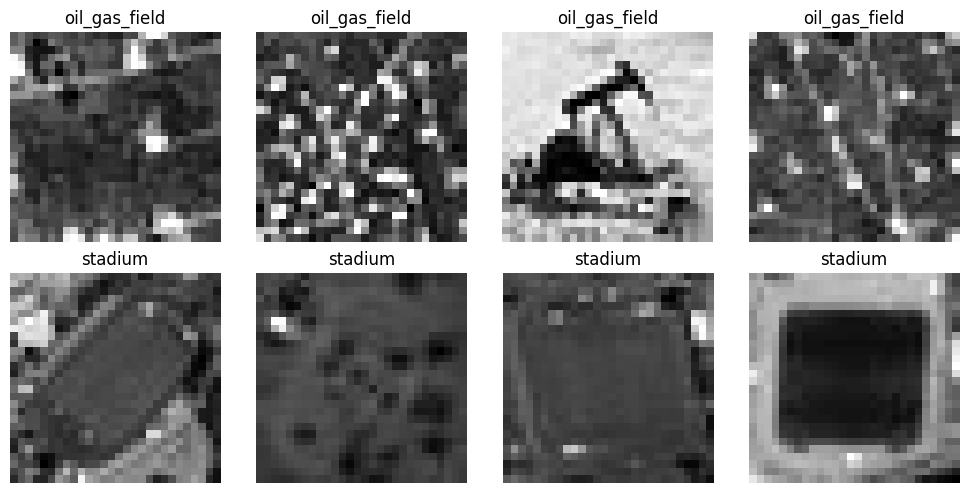

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

num_classes_to_plot = min(len(classes), 2)
images_per_class_to_plot = 4

for row, class_name in enumerate(classes[:num_classes_to_plot]):
    class_indices = np.where(train_labels == row)[0]
    if len(class_indices) < images_per_class_to_plot:
        print(f"Warning: Not enough images for class '{class_name}' to plot {images_per_class_to_plot} samples. Plotting all available samples.")
        samples = class_indices
    else:
        samples = np.random.choice(class_indices, images_per_class_to_plot, replace=False)

    for col, idx in enumerate(samples):
        image_to_display = ((train_images[idx] + 1) * 127.5).astype("uint8").squeeze()
        axes[row, col].imshow(
            image_to_display,
            cmap="gray"
        )
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## Data Splitting

Before training the GAN, the dataset is divided into three subsets:

- Training Set
- Validation Set
- Test Set

The training set is used to train the Generator and Discriminator models. The validation set is used to monitor the training process, while the test set is reserved for evaluating the generated images using the Fréchet Inception Distance (FID).

In [10]:
X_train, X_valid, y_train, y_valid = train_test_split(
    train_images,
    train_labels,
    test_size=0.10,
    stratify=train_labels,
    random_state=SEED
)

X_test = test_images
y_test = test_labels

print(f"Training Set   : {X_train.shape}")
print(f"Validation Set : {X_valid.shape}")
print(f"Testing Set    : {X_test.shape}")

Training Set   : (1557, 28, 28, 1)
Validation Set : (174, 28, 28, 1)
Testing Set    : (215, 28, 28, 1)


In [11]:
print("Training Set")
for idx, class_name in enumerate(classes):
    print(f"{class_name:<15}: {np.sum(y_train == idx)}")

print("\nValidation Set")
for idx, class_name in enumerate(classes):
    print(f"{class_name:<15}: {np.sum(y_valid == idx)}")

print("\nTesting Set")
for idx, class_name in enumerate(classes):
    print(f"{class_name:<15}: {np.sum(y_test == idx)}")

Training Set
oil_gas_field  : 799
stadium        : 758

Validation Set
oil_gas_field  : 89
stadium        : 85

Testing Set
oil_gas_field  : 110
stadium        : 105


## Baseline Generator

The Generator is responsible for generating synthetic images from random noise. It receives a latent vector together with the class label as input and gradually transforms them through several fully connected layers. The final output is a 28 × 28 grayscale image with pixel values in the range of [-1, 1] using the tanh activation function.

In [12]:
# hyperparameter
IMAGE_HEIGHT = 28
IMAGE_WIDTH = 28
CHANNELS = 1

IMAGE_SIZE = IMAGE_HEIGHT * IMAGE_WIDTH

LATENT_DIM = 100

NUM_CLASSES = len(classes)

In [13]:
def build_generator():
    noise_input = Input(shape=(LATENT_DIM,), name="Noise")
    label_input = Input(shape=(1,), name="Label")

    label_embedding = Embedding(input_dim=NUM_CLASSES, output_dim=LATENT_DIM)(label_input)
    label_embedding = Flatten()(label_embedding)

    x = Concatenate()([noise_input, label_embedding])

    hidden_units = [128, 256, 512, 1024]
    for units in hidden_units:
        x = Dense(units)(x)
        x = LeakyReLU(negative_slope=0.2)(x)
        x = BatchNormalization()(x)

    x = Dense(IMAGE_SIZE, activation="tanh")(x)
    output = Reshape((IMAGE_HEIGHT, IMAGE_WIDTH, CHANNELS))(x)

    return Model([noise_input, label_input], output, name="Generator")

generator = build_generator()
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Label (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 100)    │        200 │ Label[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Noise (InputLayer)  │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 100)       │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 200)       │          0 │ Noise[0][0],      │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     25,728 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128)       │          0 │ dense[0][0]       │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ leaky_re_lu[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     33,024 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 256)       │          0 │ dense_1[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ leaky_re_lu_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    131,584 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 512)       │          0 │ dense_2[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ leaky_re_lu_2[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1024)      │    525,312 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 1024)      │          0 │ dense_3[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ leaky_re_lu_3[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 784)       │    803,600 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 28, 28, 1) │          0 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,527,128 (5.83 MB)

 Trainable params: 1,523,288 (5.81 MB)

 Non-trainable params: 3,840 (15.00 KB)

## Baseline Discriminator

The Discriminator is responsible for distinguishing between real and generated images. It receives an input image together with its corresponding class label. Both inputs are combined and passed through several fully connected layers to classify whether the input image is real or fake. The output layer uses the sigmoid activation function to produce a probability value between 0 and 1.

In [14]:
def build_discriminator():
    image_input = Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, CHANNELS), name="Image")
    label_input = Input(shape=(1,), name="Label")

    image = Flatten()(image_input)
    label_embedding = Embedding(input_dim=NUM_CLASSES, output_dim=IMAGE_SIZE)(label_input)
    label_embedding = Flatten()(label_embedding)

    x = Concatenate()([image, label_embedding])

    hidden_units = [512, 1024]
    for units in hidden_units:
        x = Dense(units)(x)
        x = LeakyReLU(negative_slope=0.2)(x)
        x = Dropout(0.3)(x)

    output = Dense(1, activation="sigmoid")(x)

    return Model([image_input, label_input], output, name="Discriminator")

discriminator = build_discriminator()
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Label (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Image (InputLayer)  │ (None, 28, 28, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 784)    │      1,568 │ Label[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 784)       │          0 │ Image[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 784)       │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1568)      │          0 │ flatten_1[0][0],  │
│ (Concatenate)       │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 512)       │    803,328 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 512)       │          0 │ dense_5[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ leaky_re_lu_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1024)      │    525,312 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 1024)      │          0 │ dense_6[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1024)      │          0 │ leaky_re_lu_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │      1,025 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,331,233 (5.08 MB)

 Trainable params: 1,331,233 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# compile discriminator
optimizer = Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### Discriminator Configuration

The Discriminator is optimized using the Adam optimizer with a learning rate of **0.0002** and **β₁ = 0.5**, which are commonly used hyperparameters for stabilizing GAN training. Binary Crossentropy is employed as the loss function because the Discriminator performs binary classification between real and fake images.

## Baseline Conditional GAN

The Conditional GAN (cGAN) combines the Generator and the Discriminator into a single model. During Generator training, the Discriminator weights are frozen so that only the Generator is updated. The Generator learns to produce realistic images that can successfully fool the Discriminator into predicting them as real.

In [16]:
discriminator.trainable = False
noise = Input(shape=(LATENT_DIM,), name="Noise_Input")
label = Input(shape=(1,), name="Label_Input")
generated_image = generator([noise, label])
validity = discriminator([generated_image, label])

gan = Model(
    inputs=[noise, label],
    outputs=validity,
    name="Conditional_GAN"
)

gan.compile(
    optimizer=Adam(
        learning_rate=0.0002,
        beta_1=0.5
    ),
    loss="binary_crossentropy"
)

gan.summary()

Model: "Conditional_GAN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Noise_Input         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Label_Input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Generator           │ (None, 28, 28, 1) │  1,527,128 │ Noise_Input[0][0… │
│ (Functional)        │                   │            │ Label_Input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Discriminator       │ (None, 1)         │  1,331,233 │ Generator[0][0],  │
│ (Functional)        │                   │            │ Label_Input[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,858,361 (10.90 MB)

 Trainable params: 1,523,288 (5.81 MB)

 Non-trainable params: 1,335,073 (5.09 MB)

### GAN Training Strategy

The Generator and Discriminator are trained alternately.

- The Discriminator learns to distinguish between real and fake images.
- The Generator learns to generate images that can fool the Discriminator.

This adversarial training process continues until the Generator can produce realistic images that resemble the training dataset.

In [17]:
# training configuration
EPOCHS = 100
BATCH_SIZE = 64
SAVE_INTERVAL = 50

REAL_LABEL = np.ones((BATCH_SIZE, 1))
FAKE_LABEL = np.zeros((BATCH_SIZE, 1))

## Visualization Function

To monitor the Generator's learning progress, generated images are displayed periodically during training. As the number of epochs increases, the generated images are expected to become more realistic and visually similar to the original dataset.

In [18]:
def generate_images(epoch, rows=2, cols=5):
    noise = np.random.normal(0, 1, (rows * cols, LATENT_DIM))
    labels = np.array([i % NUM_CLASSES for i in range(rows * cols)]).reshape(-1, 1)

    # Prediksi & Rescale gambar dari [-1, 1] ke [0, 1]
    generated = generator.predict([noise, labels], verbose=0)
    generated = (generated + 1) / 2.0

    fig, axes = plt.subplots(rows, cols, figsize=(10, 4))

    for i, ax in enumerate(axes.flatten()):
        ax.imshow(generated[i].squeeze(), cmap="gray")
        ax.set_title(classes[labels[i][0]], fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## Baseline GAN Training

The Generator and Discriminator are trained alternately during each epoch.

For every iteration:

1. A batch of real images is sampled from the training dataset.
2. Random noise is generated and transformed into fake images by the Generator.
3. The Discriminator is trained using both real and fake images.
4. The Generator is then updated through the combined GAN model to produce more realistic images.
5. Generated images are displayed periodically to monitor the learning progress.

In [19]:
def train_gan(generator, discriminator, gan, X_train, y_train, epochs, batch_size):
    half_batch = batch_size // 2
    d_loss_history, g_loss_history = [], []

    for epoch in range(epochs):
        discriminator.trainable = True
        idx = np.random.randint(0, X_train.shape[0], half_batch)
        real_images, real_labels = X_train[idx], y_train[idx].reshape(-1, 1)

        noise = np.random.normal(0, 1, (half_batch, LATENT_DIM))
        fake_labels = np.random.randint(0, NUM_CLASSES, (half_batch, 1))
        fake_images = generator.predict([noise, fake_labels], verbose=0)

        real_loss = discriminator.train_on_batch([real_images, real_labels], np.ones((half_batch, 1)))
        fake_loss = discriminator.train_on_batch([fake_images, fake_labels], np.zeros((half_batch, 1)))
        d_loss = 0.5 * np.add(real_loss, fake_loss)

        discriminator.trainable = False

        noise = np.random.normal(0, 1, (batch_size, LATENT_DIM))
        sampled_labels = np.random.randint(0, NUM_CLASSES, (batch_size, 1))

        g_loss = gan.train_on_batch([noise, sampled_labels], np.ones((batch_size, 1)))

        # Simpan History Loss
        d_loss_history.append(d_loss[0])
        g_loss_history.append(g_loss)

        # Cetak Progress & Simpan Gambar
        if (epoch + 1) % SAVE_INTERVAL == 0:
            print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_loss[0]:.4f} | D Acc: {100*d_loss[1]:.2f}% | G Loss: {g_loss:.4f}")
            generate_images(epoch + 1)

    return d_loss_history, g_loss_history

Epoch 50/100 | D Loss: 0.2684 | D Acc: 93.81% | G Loss: 0.1272


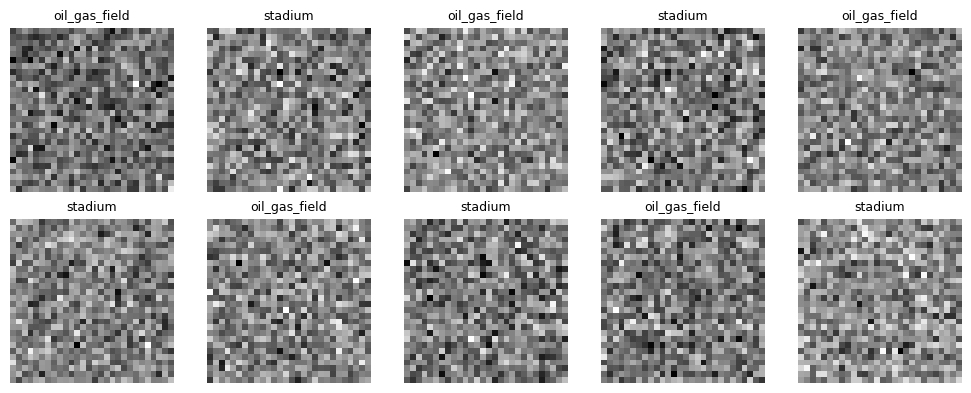

Epoch 100/100 | D Loss: 0.2429 | D Acc: 92.65% | G Loss: 0.1558


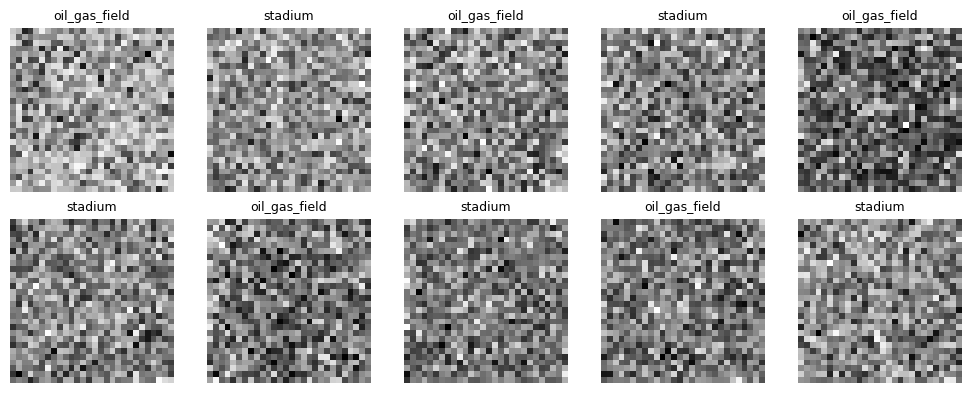

In [20]:
d_loss_history, g_loss_history = train_gan(
    generator,
    discriminator,
    gan,
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

## Baseline Training Performance

The Generator loss and Discriminator loss are plotted to observe the training behavior of the GAN. Stable training is indicated when both losses fluctuate within a reasonable range without diverging.

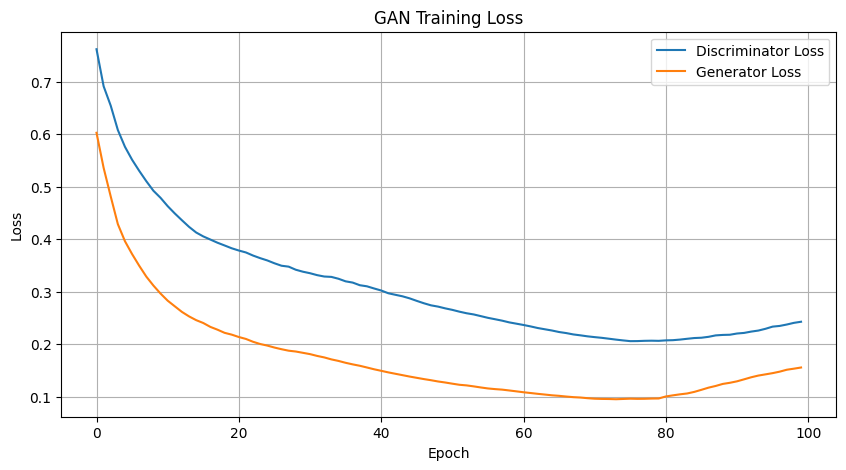

In [21]:
plt.figure(figsize=(10,5))

plt.plot(
    d_loss_history,
    label="Discriminator Loss"
)

plt.plot(
    g_loss_history,
    label="Generator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")

plt.legend()

plt.grid(True)

plt.show()

## Baseline Generated Images

After training, the Generator is expected to produce images that resemble the real images from the training dataset. Random noise vectors are sampled from the latent space and transformed into synthetic images conditioned on the selected class labels.

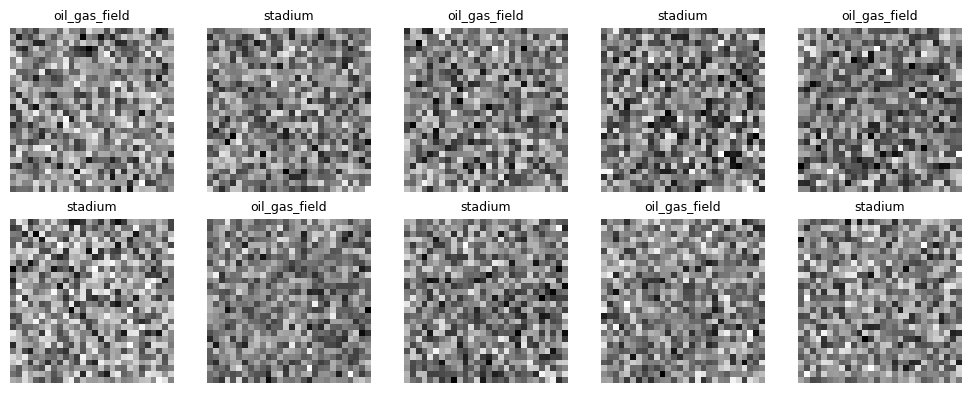

In [22]:
generate_images(epoch=EPOCHS)

## Baseline FID Evaluation

The Frechet Inception Distance (FID) is used to evaluate the quality of generated images by comparing their feature distribution with that of real images. A lower FID score indicates that the generated images are more similar to the real dataset.

In [23]:
fid_model = InceptionV3(
    include_top=False,
    pooling="avg",
    input_shape=(299, 299, 3)
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [24]:
def preprocess_images(images):
    images = (images + 1) / 2.0
    images = tf.image.resize(images, (299,299))
    images = tf.image.grayscale_to_rgb(images)
    images = preprocess_input(images)

    return images.numpy()

In [25]:
def generate_fake_images(generator, n_samples):
    noise = np.random.normal(
        0,
        1,
        (n_samples, LATENT_DIM)
    )

    labels = np.random.randint(
        0,
        NUM_CLASSES,
        (n_samples,1)
    )

    fake_images = generator.predict(
        [noise, labels],
        verbose=0
    )

    return fake_images

In [26]:
from scipy.linalg import sqrtm

def calculate_fid(real_images, fake_images):
    act_real = fid_model.predict(preprocess_images(real_images), verbose=0)
    act_fake = fid_model.predict(preprocess_images(fake_images), verbose=0)

    mu_real, mu_fake = np.mean(act_real, axis=0), np.mean(act_fake, axis=0)
    sigma_real = np.cov(act_real, rowvar=False)
    sigma_fake = np.cov(act_fake, rowvar=False)

    diff = mu_real - mu_fake
    covmean = sqrtm(sigma_real.dot(sigma_fake))

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    # Hitung nilai akhir FID
    fid = diff.dot(diff) + np.trace(sigma_real + sigma_fake - 2 * covmean)
    return fid

In [27]:
fake_images = generate_fake_images(
    generator,
    len(X_test)
)

fid_score = calculate_fid(
    X_test,
    fake_images
)

print(f"Baseline GAN FID : {fid_score:.2f}")

Baseline GAN FID : 2.29


/tmp/ipykernel_3290/3990690272.py:13: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma_real.dot(sigma_fake))


# Improved GAN Architecture

To improve the image generation performance, several modifications are introduced to the baseline Conditional GAN.

The improvements include:

- Increasing the network capacity by adding more neurons.
- Adding additional Batch Normalization layers to stabilize training.
- Increasing the Dropout rate in the Discriminator to reduce overfitting.
- Using a smaller learning rate for smoother optimization.
- Increasing the number of training epochs.

These modifications are expected to improve the Generator's ability to learn the underlying image distribution, resulting in a lower Fréchet Inception Distance (FID).

In [34]:
# hyperparameter
IMPROVED_LATENT_DIM = 128
IMPROVED_BATCH_SIZE = 64
IMPROVED_EPOCHS = 1000
IMPROVED_LR = 0.0001
IMPROVED_BETA1 = 0.5

In [35]:
def build_improved_generator():
    noise_input = Input(
        shape=(IMPROVED_LATENT_DIM,),
        name="Noise_Input"
    )

    label_input = Input(
        shape=(1,),
        name="Label_Input"
    )

    label_embedding = Embedding(
        input_dim=NUM_CLASSES,
        output_dim=IMPROVED_LATENT_DIM
    )(label_input)

    label_embedding = Flatten()(label_embedding)
    x = Concatenate()([noise_input, label_embedding])

    # Hidden Layer 1
    x = Dense(256)(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = BatchNormalization()(x)

    # Hidden Layer 2
    x = Dense(512)(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = BatchNormalization()(x)

    # Hidden Layer 3
    x = Dense(1024)(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = BatchNormalization()(x)

    # Hidden Layer 4 (Improvement)
    x = Dense(1024)(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.20)(x)

    # Output Layer
    x = Dense(
        IMAGE_SIZE,
        activation="tanh"
    )(x)

    output = Reshape(
        (IMAGE_HEIGHT, IMAGE_WIDTH, CHANNELS)
    )(x)

    improved_generator = Model(
        inputs=[noise_input, label_input],
        outputs=output,
        name="Improved_Generator"
    )

    return improved_generator


improved_generator = build_improved_generator()
improved_generator.summary()

Model: "Improved_Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Label_Input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 128)    │        256 │ Label_Input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Noise_Input         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 128)       │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 256)       │          0 │ Noise_Input[0][0… │
│ (Concatenate)       │                   │            │ flatten_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 256)       │     65,792 │ concatenate_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_13      │ (None, 256)       │          0 │ dense_17[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ leaky_re_lu_13[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 512)       │    131,584 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_14      │ (None, 512)       │          0 │ dense_18[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ leaky_re_lu_14[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 1024)      │    525,312 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_15      │ (None, 1024)      │          0 │ dense_19[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ leaky_re_lu_15[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 1024)      │  1,049,600 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_16      │ (None, 1024)      │          0 │ dense_20[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ leaky_re_lu_16[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 1024)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 784)       │    803,600 │ dropout_5[0][0] 

 Total params: 2,587,408 (9.87 MB)

 Trainable params: 2,581,776 (9.85 MB)

 Non-trainable params: 5,632 (22.00 KB)

In [36]:
def build_improved_discriminator():
    image_input = Input(
        shape=(IMAGE_HEIGHT, IMAGE_WIDTH, CHANNELS),
        name="Image_Input"
    )

    label_input = Input(
        shape=(1,),
        name="Label_Input"
    )

    image = Flatten()(image_input)
    label_embedding = Embedding(
        input_dim=NUM_CLASSES,
        output_dim=IMAGE_SIZE
    )(label_input)

    label_embedding = Flatten()(label_embedding)

    # Concatenate image and label
    x = Concatenate()([image, label_embedding])

    # Hidden Layer 1
    x = Dense(1024)(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = Dropout(0.30)(x)

    # Hidden Layer 2
    x = Dense(512)(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = Dropout(0.30)(x)

    # Hidden Layer 3 (Improvement)
    x = Dense(256)(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = Dropout(0.30)(x)

    # Output Layer
    output = Dense(
        1,
        activation="sigmoid"
    )(x)

    improved_discriminator = Model(
        inputs=[image_input, label_input],
        outputs=output,
        name="Improved_Discriminator"
    )

    return improved_discriminator

improved_discriminator = build_improved_discriminator()
improved_discriminator.summary()

Model: "Improved_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Label_Input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Image_Input         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 1, 784)    │      1,568 │ Label_Input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 784)       │          0 │ Image_Input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 784)       │          0 │ embedding_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 1568)      │          0 │ flatten_7[0][0],  │
│ (Concatenate)       │                   │            │ flatten_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 1024)      │  1,606,656 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_17      │ (None, 1024)      │          0 │ dense_22[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 1024)      │          0 │ leaky_re_lu_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 512)       │    524,800 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_18      │ (None, 512)       │          0 │ dense_23[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 512)       │          0 │ leaky_re_lu_18[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 256)       │    131,328 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_19      │ (None, 256)       │          0 │ dense_24[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 256)       │          0 │ leaky_re_lu_19[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 1)         │        257 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,264,609 (8.64 MB)

 Trainable params: 2,264,609 (8.64 MB)

 Non-trainable params: 0 (0.00 B)

## Compile Improved Discriminator

The improved Discriminator is compiled using the Adam optimizer with a lower learning rate than the baseline model. A smaller learning rate helps stabilize the adversarial training process and reduces the risk of unstable parameter updates.

In [37]:
improved_discriminator_optimizer = Adam(
    learning_rate=IMPROVED_LR,
    beta_1=IMPROVED_BETA1
)

improved_discriminator.compile(
    optimizer=improved_discriminator_optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Build Improved Conditional GAN

The improved Generator and Discriminator are combined into a Conditional GAN model. During Generator training, the Discriminator parameters are frozen so that only the Generator is updated. This enables the Generator to improve its ability to produce realistic images conditioned on the input class labels.

In [38]:
# Freeze Discriminator
improved_discriminator.trainable = False

# GAN Inputs
noise_input = Input(
    shape=(IMPROVED_LATENT_DIM,),
    name="Noise_Input"
)

label_input = Input(
    shape=(1,),
    name="Label_Input"
)

# Generate Fake Image
generated_image = improved_generator(
    [noise_input, label_input]
)

# Classify Fake Image
validity = improved_discriminator(
    [generated_image, label_input]
)

improved_gan = Model(
    inputs=[noise_input, label_input],
    outputs=validity,
    name="Improved_Conditional_GAN"
)

improved_gan_optimizer = Adam(
    learning_rate=IMPROVED_LR,
    beta_1=IMPROVED_BETA1
)

improved_gan.compile(
    optimizer=improved_gan_optimizer,
    loss="binary_crossentropy"
)

improved_gan.summary()

Model: "Improved_Conditional_GAN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Noise_Input         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Label_Input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Improved_Generator  │ (None, 28, 28, 1) │  2,587,408 │ Noise_Input[0][0… │
│ (Functional)        │                   │            │ Label_Input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Improved_Discrimin… │ (None, 1)         │  2,264,609 │ Improved_Generat… │
│ (Functional)        │                   │            │ Label_Input[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,852,017 (18.51 MB)

 Trainable params: 2,581,776 (9.85 MB)

 Non-trainable params: 2,270,241 (8.66 MB)

## Training Improved GAN

The improved Conditional GAN is trained using the same adversarial learning strategy as the baseline model. However, the tuned hyperparameters and modified architecture are expected to improve training stability and generate higher-quality images.

In [39]:
def train_gan(generator, discriminator, gan, X_train, y_train, epochs, batch_size, latent_dim):
    half_batch = batch_size // 2
    d_loss_history, g_loss_history = [], []

    for epoch in range(epochs):
        discriminator.trainable = True
        idx = np.random.randint(0, X_train.shape[0], half_batch)
        real_images, real_labels = X_train[idx], y_train[idx].reshape(-1, 1)

        noise = np.random.normal(0, 1, (half_batch, latent_dim))
        fake_labels = np.random.randint(0, NUM_CLASSES, (half_batch, 1))
        fake_images = generator.predict([noise, fake_labels], verbose=0)

        real_loss = discriminator.train_on_batch([real_images, real_labels], np.ones((half_batch, 1)))
        fake_loss = discriminator.train_on_batch([fake_images, fake_labels], np.zeros((half_batch, 1)))
        d_loss = 0.5 * np.add(real_loss, fake_loss)

        discriminator.trainable = False

        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        sampled_labels = np.random.randint(0, NUM_CLASSES, (batch_size, 1))

        g_loss = gan.train_on_batch([noise, sampled_labels], np.ones((batch_size, 1)))

        # Simpan History Loss
        d_loss_history.append(d_loss[0])
        g_loss_history.append(g_loss)

        # Cetak Progress & Simpan Gambar
        if (epoch + 1) % SAVE_INTERVAL == 0:
            print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_loss[0]:.4f} | D Acc: {100*d_loss[1]:.2f}% | G Loss: {g_loss:.4f}")
            generate_images(epoch + 1)

    return d_loss_history, g_loss_history

Epoch 50/1000 | D Loss: 0.3052 | D Acc: 94.66% | G Loss: 0.2748


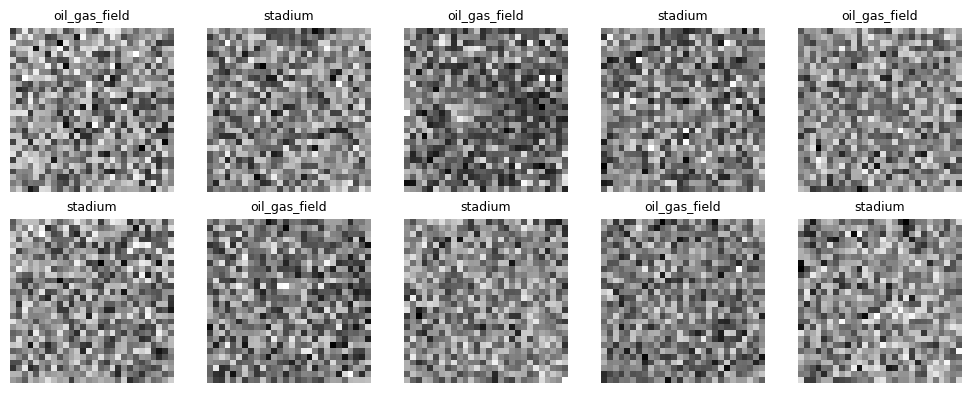

Epoch 100/1000 | D Loss: 0.1707 | D Acc: 97.01% | G Loss: 0.1513


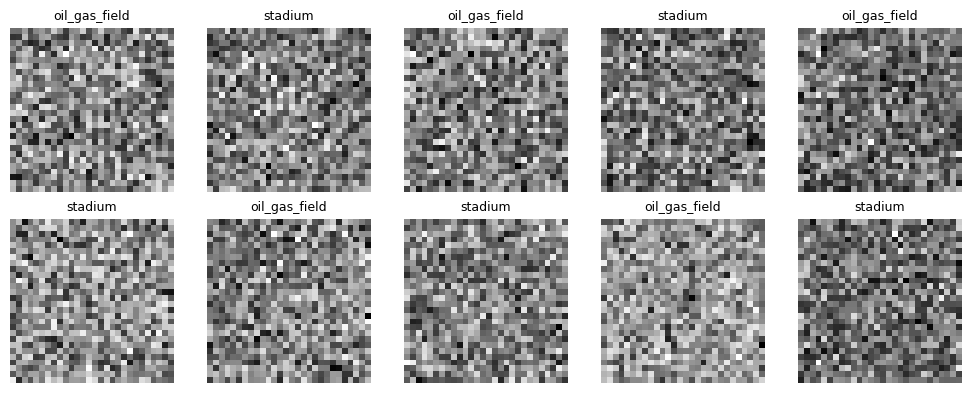

Epoch 150/1000 | D Loss: 0.1318 | D Acc: 97.28% | G Loss: 0.1750


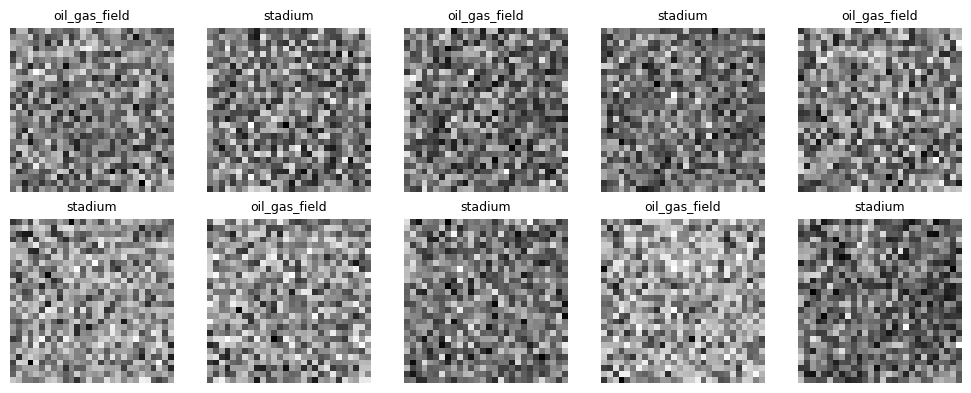

Epoch 200/1000 | D Loss: 0.1874 | D Acc: 94.03% | G Loss: 0.7174


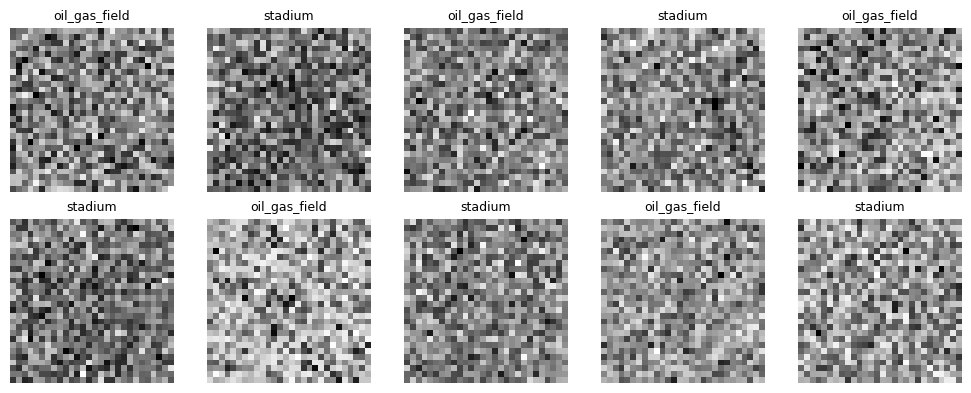

Epoch 250/1000 | D Loss: 0.2419 | D Acc: 91.16% | G Loss: 1.1403


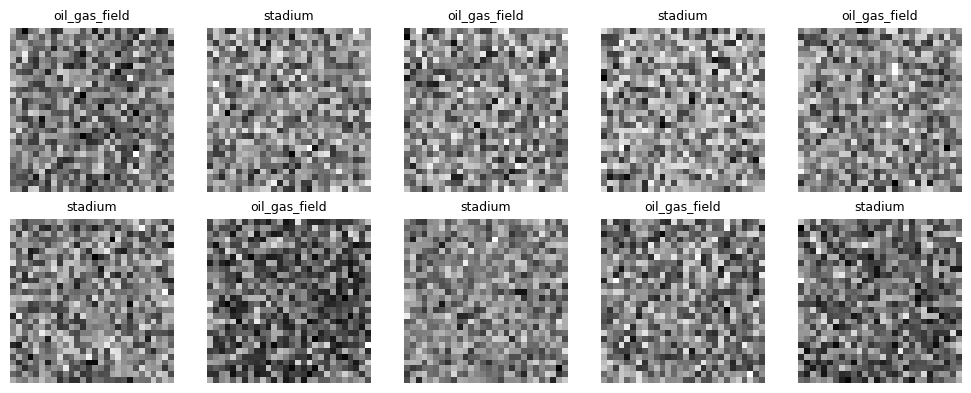

Epoch 300/1000 | D Loss: 0.2578 | D Acc: 90.35% | G Loss: 1.5277


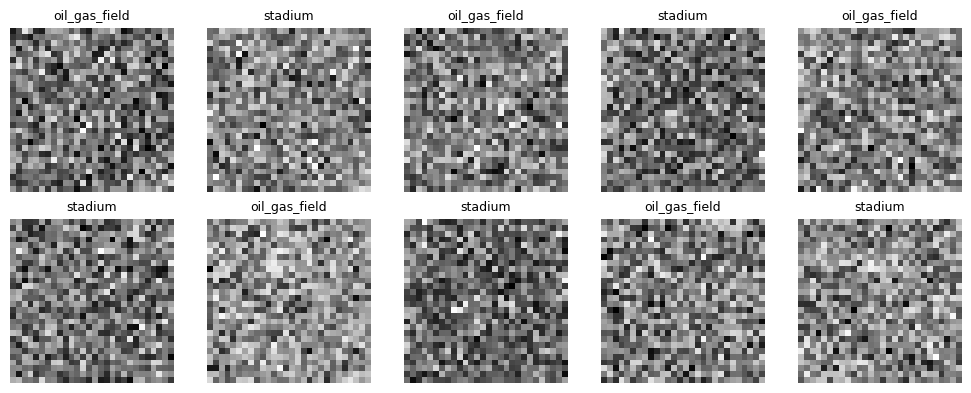

Epoch 350/1000 | D Loss: 0.2564 | D Acc: 90.41% | G Loss: 1.8811


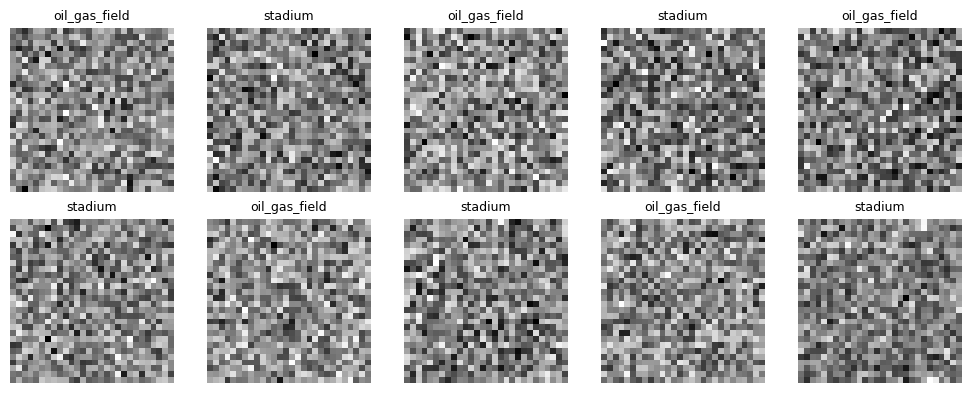

Epoch 400/1000 | D Loss: 0.2533 | D Acc: 90.52% | G Loss: 2.1694


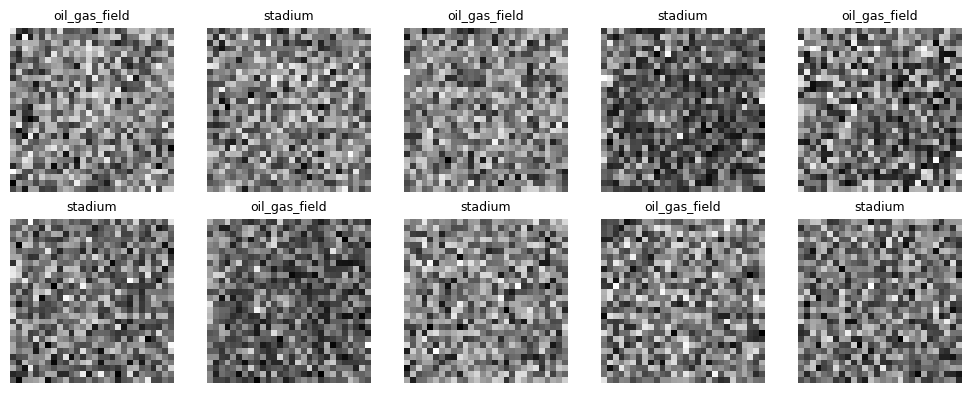

Epoch 450/1000 | D Loss: 0.2518 | D Acc: 90.54% | G Loss: 2.3618


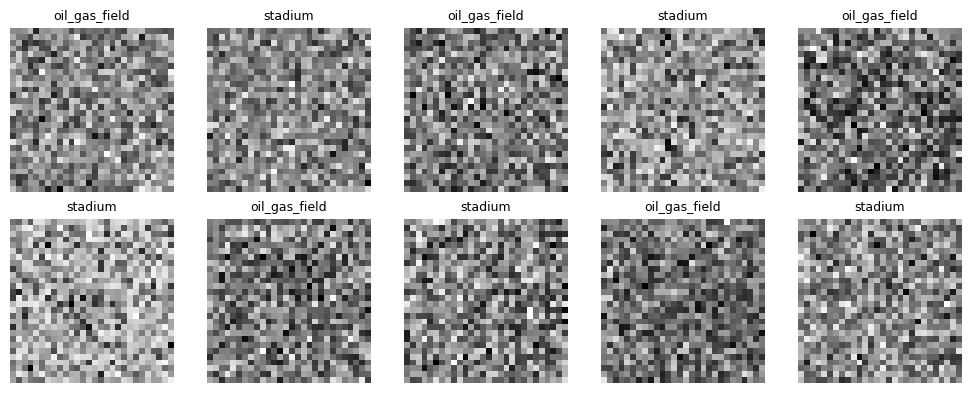

Epoch 500/1000 | D Loss: 0.2508 | D Acc: 90.50% | G Loss: 2.5087


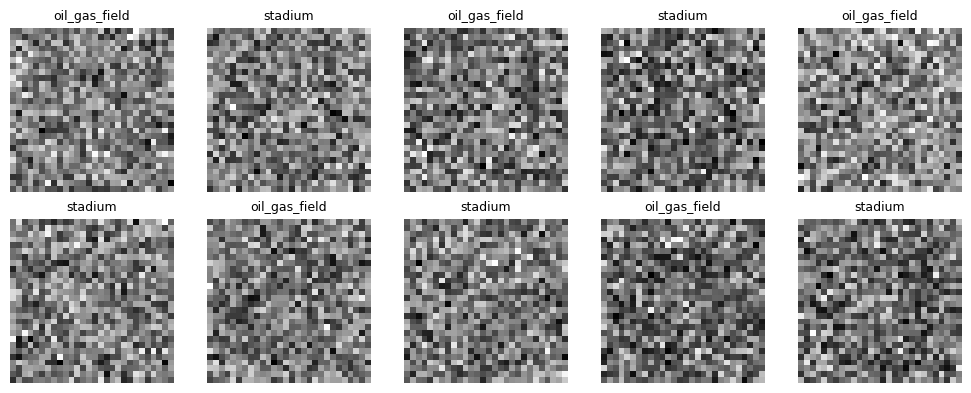

Epoch 550/1000 | D Loss: 0.2564 | D Acc: 90.18% | G Loss: 2.6319


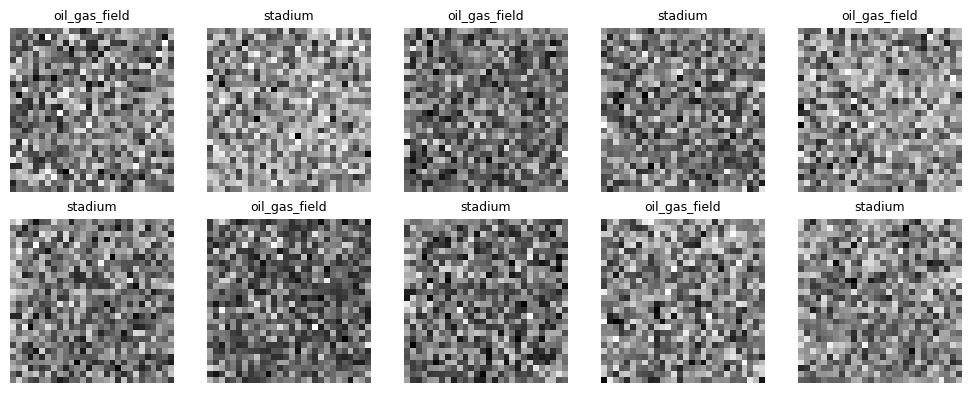

Epoch 600/1000 | D Loss: 0.2695 | D Acc: 89.40% | G Loss: 2.7305


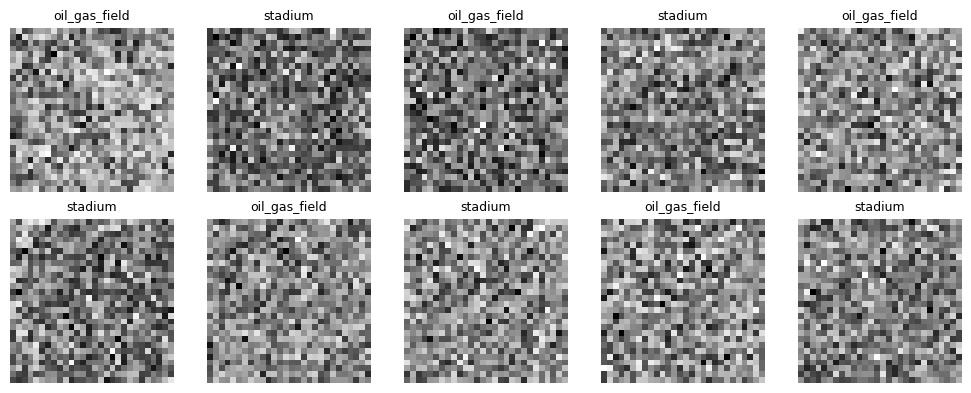

Epoch 650/1000 | D Loss: 0.2818 | D Acc: 88.63% | G Loss: 2.7878


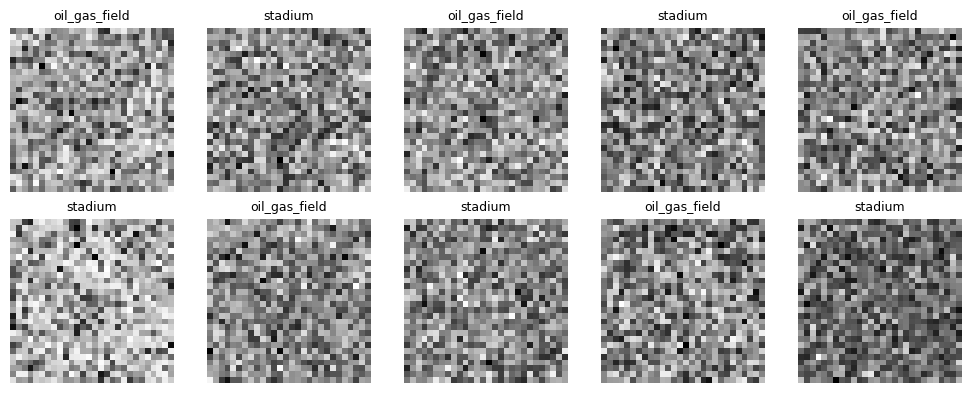

Epoch 700/1000 | D Loss: 0.2971 | D Acc: 87.69% | G Loss: 2.8347


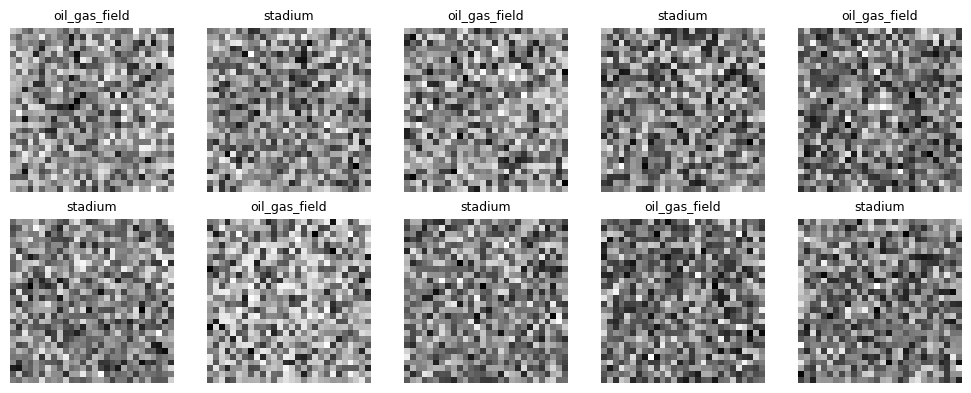

Epoch 750/1000 | D Loss: 0.3147 | D Acc: 86.54% | G Loss: 2.8473


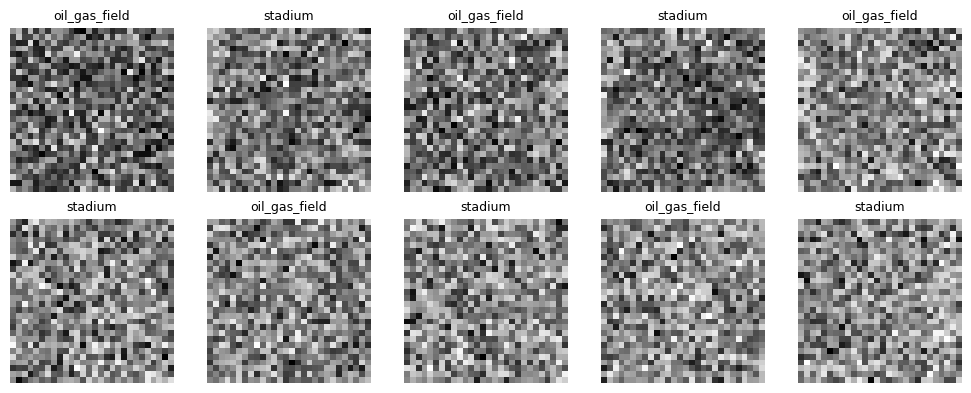

Epoch 800/1000 | D Loss: 0.3337 | D Acc: 85.41% | G Loss: 2.8418


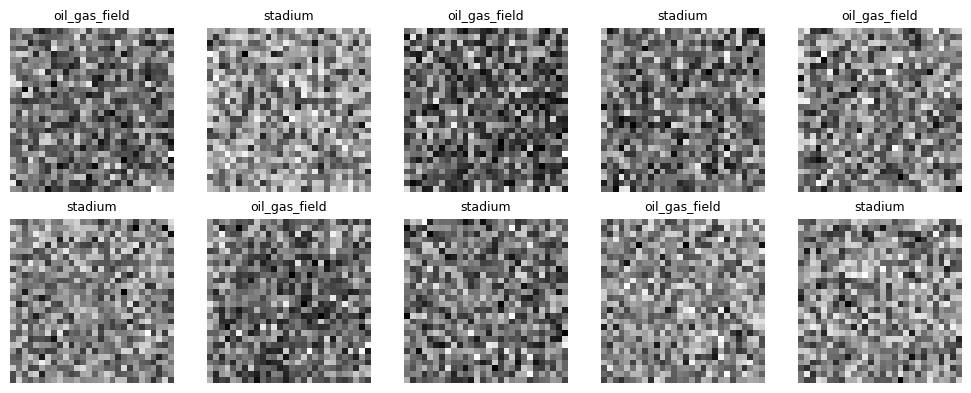

Epoch 850/1000 | D Loss: 0.3516 | D Acc: 84.21% | G Loss: 2.8141


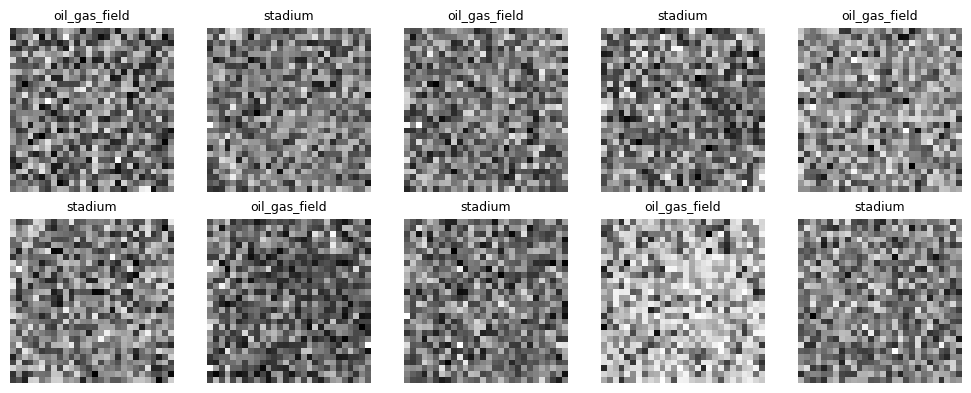

Epoch 900/1000 | D Loss: 0.3658 | D Acc: 83.22% | G Loss: 2.7778


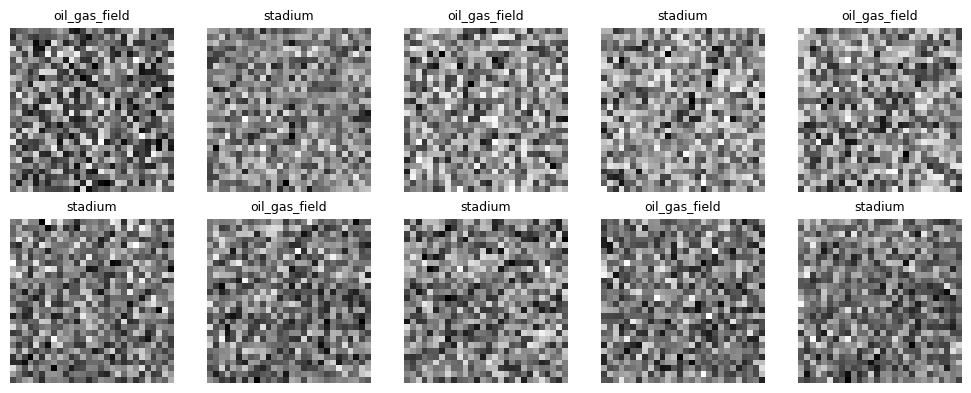

Epoch 950/1000 | D Loss: 0.3818 | D Acc: 82.00% | G Loss: 2.7330


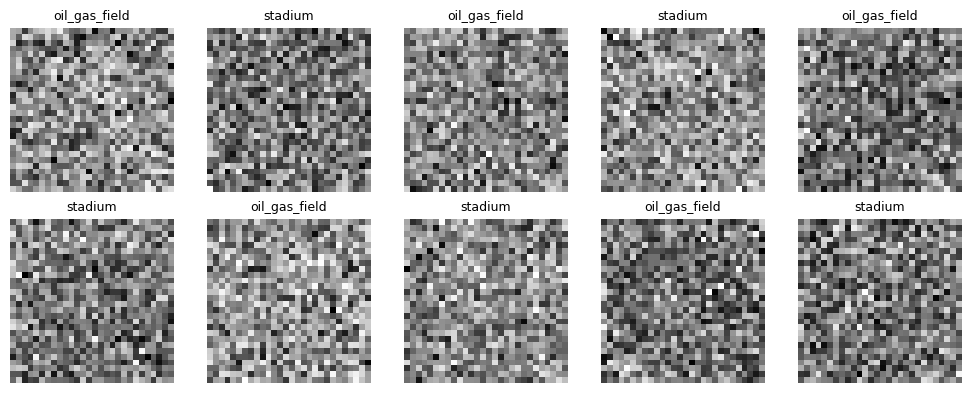

Epoch 1000/1000 | D Loss: 0.3942 | D Acc: 81.11% | G Loss: 2.6837


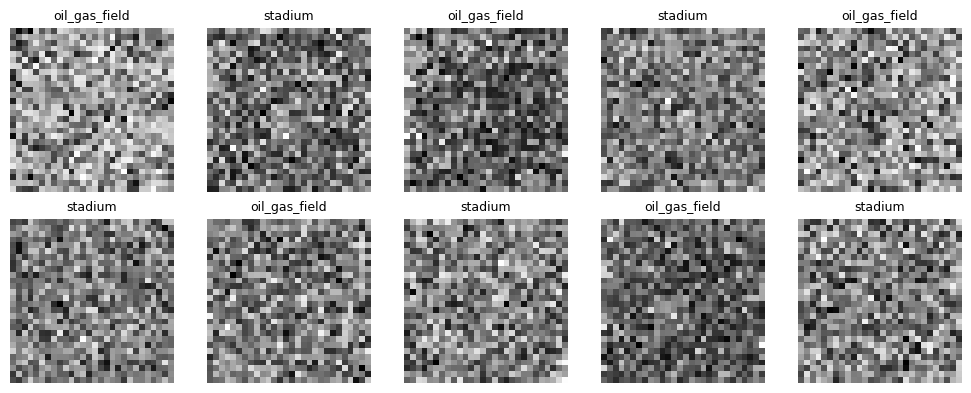

In [40]:
improved_d_loss_history, improved_g_loss_history = train_gan(
    generator=improved_generator,
    discriminator=improved_discriminator,
    gan=improved_gan,
    X_train=X_train,
    y_train=y_train,
    epochs=IMPROVED_EPOCHS,
    batch_size=IMPROVED_BATCH_SIZE,
    latent_dim=IMPROVED_LATENT_DIM
)

## Improved Training Performance

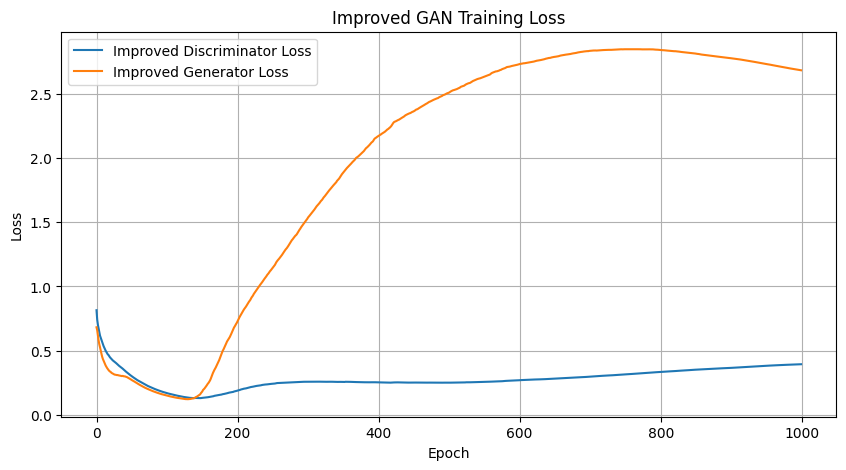

In [41]:
plt.figure(figsize=(10,5))

plt.plot(
    improved_d_loss_history,
    label="Improved Discriminator Loss"
)

plt.plot(
    improved_g_loss_history,
    label="Improved Generator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved GAN Training Loss")

plt.legend()

plt.grid(True)

plt.show()

In [43]:
def generate_images(generator, epoch, latent_dim, rows=2, cols=5):
    noise = np.random.normal(0, 1, (rows * cols, latent_dim))
    labels = np.array([i % NUM_CLASSES for i in range(rows * cols)]).reshape(-1, 1)

    # Prediksi & Rescale gambar dari [-1, 1] ke [0, 1]
    generated = generator.predict([noise, labels], verbose=0)
    generated = (generated + 1) / 2.0

    fig, axes = plt.subplots(rows, cols, figsize=(10, 4))

    for i, ax in enumerate(axes.flatten()):
        ax.imshow(generated[i].squeeze(), cmap="gray")
        ax.set_title(classes[labels[i][0]], fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [44]:
def generate_fake_images(generator, latent_dim, n_samples):
    noise = np.random.normal(
        0,
        1,
        (n_samples, latent_dim)
    )

    labels = np.random.randint(
        0,
        NUM_CLASSES,
        (n_samples,1)
    )

    fake_images = generator.predict(
        [noise, labels],
        verbose=0
    )

    return fake_images

In [45]:
# Improved fid
improved_fake_images = generate_fake_images(
    improved_generator,
    IMPROVED_LATENT_DIM,
    len(X_test)
)

improved_fid = calculate_fid(
    X_test,
    improved_fake_images
)

print(f"Improved GAN FID : {improved_fid:.2f}")

Improved GAN FID : 1.51


/tmp/ipykernel_3290/3990690272.py:13: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma_real.dot(sigma_fake))


# Performance Comparison

The baseline and improved Conditional GAN models are compared using the Frechet Inception Distance (FID). A lower FID score indicates better similarity between the generated images and the real images.

In [47]:
import pandas as pd
comparison = pd.DataFrame({
    "Model": [
        "Baseline GAN",
        "Improved GAN"
    ],
    "FID Score": [
        fid_score,
        improved_fid
    ]
})

comparison

,Model,FID Score
0,Baseline GAN,2.288711
1,Improved GAN,1.511260


Baseline GAN


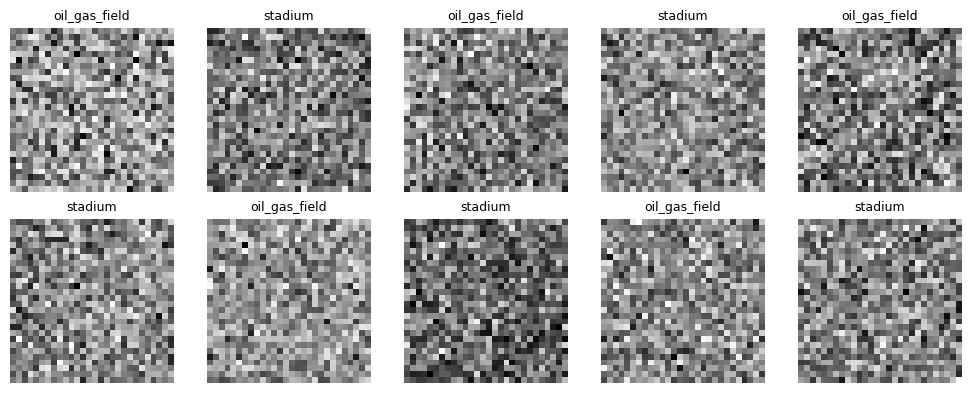

Improved GAN


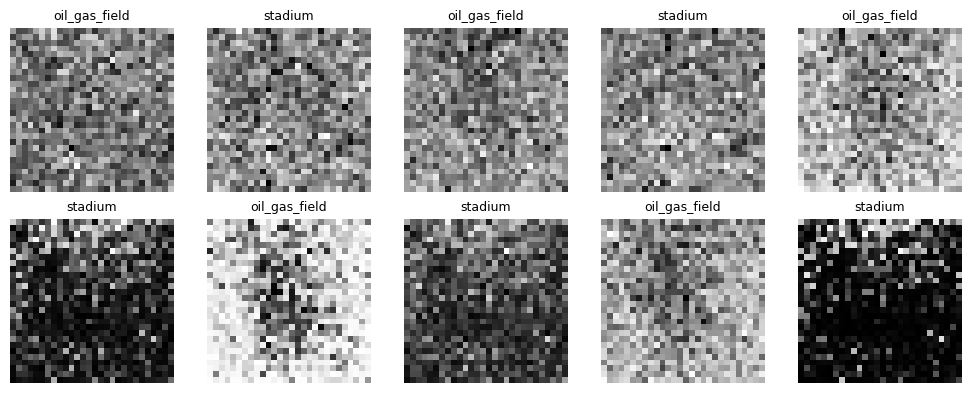

In [56]:
print("Baseline GAN")
generate_images(
    generator,
    EPOCHS,
    LATENT_DIM
)

print("Improved GAN")
generate_images(
    improved_generator,
    IMPROVED_EPOCHS,
    IMPROVED_LATENT_DIM
)

# Result Analysis

The baseline Conditional GAN achieved an FID score of **2.289**, while the improved Conditional GAN achieved an FID score of **1.511**.

The improved model reduced the FID score by approximately **34%**, indicating that the generated images achieved a better feature distribution similarity to the real images according to the FID evaluation metric.

The performance improvement was achieved through several modifications:

- Increasing the latent dimension from 100 to 128.
- Adding an additional hidden layer in both the Generator and the Discriminator.
- Applying Batch Normalization in the Generator.
- Applying Dropout in the Discriminator.
- Reducing the learning rate from 0.0002 to 0.0001.
- Increasing the number of training epochs from 100 to 1000.

Overall, these modifications resulted in more stable adversarial training and a lower FID score. Although the generated images still contain noticeable noise, the improved FID indicates a better similarity between the generated and real image feature distributions. Future improvements may include training for more epochs, using convolutional GAN architectures, or applying more advanced GAN variants to further enhance visual quality.

# Conclusion

This project successfully implemented a Conditional Generative Adversarial Network (cGAN) using the Overhead-MNIST dataset for image generation.

Two different models were evaluated:

- Baseline Conditional GAN
- Improved Conditional GAN

Experimental results showed that the improved model achieved a lower Fréchet Inception Distance (FID) score than the baseline model.

The FID score decreased from **2.289** to **1.511**, representing an improvement of approximately **34%**.

The results demonstrate that the applied architectural modifications and hyperparameter tuning improved the evaluation metric (FID). However, the generated images still show visible noise, indicating that further optimization may be required to achieve better visual quality.

Future work may include using convolutional GAN architectures, larger datasets, or longer training to further improve the visual quality of the generated images.